***Постановка задачи***

HR-аналитики компании «Работа с заботой» помогают бизнесу оптимизировать управление персоналом: бизнес предоставляет данные, а аналитики предлагают, как избежать финансовых потерь и оттока сотрудников. В этом HR-аналитикам пригодится машинное обучение, с помощью которого получится быстрее и точнее отвечать на вопросы бизнеса.
Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён. 
Собирать данные такими опросниками не так легко: компания большая, и всех сотрудников надо сначала оповестить об опросе, а затем проследить, что все его прошли. 

Первая — построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика. 
Почему бизнесу это важно: удовлетворённость работой напрямую влияет на отток сотрудников. А предсказание оттока — одна из важнейших задач HR-аналитиков. Внезапные увольнения несут в себе риски для компании, особенно если уходит важный сотрудник.

Вторая задача — построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.


***Задача 1 предсказание уровня удовлетворённости сотрудника***

Для этой задачи заказчик предоставил данные с признаками:
    id — уникальный идентификатор сотрудника;
    dept — отдел, в котором работает сотрудник;
    level — уровень занимаемой должности;
    workload — уровень загруженности сотрудника;
    employment_years — длительность работы в компании (в годах);
    last_year_promo — показывает, было ли повышение за последний год;
    last_year_violations — показывает, нарушал ли сотрудник трудовой договор за последний год;
    supervisor_evaluation — оценка качества работы сотрудника, которую дал руководитель;
    salary — ежемесячная зарплата сотрудника;
    job_satisfaction_rate — уровень удовлетворённости сотрудника работой в компании, целевой признак.

***Шаг 1 Загрузка данных***

In [1]:
!pip install scikit-learn==1.1.3 matplotlib==3.5.2 phik shap -q
from sklearn.datasets import make_classification
from phik import phik_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer
from sklearn.metrics import roc_auc_score
from sklearn.dummy import DummyRegressor, DummyClassifier

from sklearn.tree import plot_tree

In [2]:
train_job_satisfaction = pd.read_csv('/datasets/train_job_satisfaction_rate.csv')

In [3]:
train_job_satisfaction 

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20
...,...,...,...,...,...,...,...,...,...,...
3995,457950,technology,junior,high,2,no,no,3,46800,0.45
3996,957499,sales,junior,medium,2,no,no,4,21600,0.68
3997,533318,sales,middle,low,7,no,no,5,24000,0.76
3998,706868,sales,junior,medium,2,no,no,3,24000,0.48


In [4]:
test_features = pd.read_csv('/datasets/test_features.csv')

In [5]:
test_features

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800
...,...,...,...,...,...,...,...,...,...
1995,393147,marketing,junior,low,3,no,no,3,20400
1996,109582,technology,middle,low,3,no,no,2,21600
1997,305653,technology,junior,low,1,no,no,3,14400
1998,160233,technology,middle,low,8,no,no,1,32400


In [6]:
test_target_job_satisfaction_rate = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv')

In [7]:
test_target_job_satisfaction_rate

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08
...,...,...
1995,405257,0.28
1996,370925,0.21
1997,857722,0.39
1998,303402,0.26


***Промежуточный вывод по Шагу 1: видим, что данные в таблицах соответствуют описанию***

***Шаг 2 Предобработка данных***

Проверим данные на пропуски

In [8]:
train_job_satisfaction.isnull().sum()

id                       0
dept                     6
level                    4
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
job_satisfaction_rate    0
dtype: int64

In [9]:
train_job_satisfaction[train_job_satisfaction['dept'].isnull()]

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
1526,694746,NaN,junior,medium,5,no,no,4,21600,0.62
1630,814624,NaN,junior,medium,3,no,no,4,24000,0.88
1633,475114,NaN,junior,high,4,no,no,4,31200,0.63
2781,497243,NaN,junior,medium,1,no,no,3,26400,0.28
2975,168668,NaN,junior,low,3,no,no,4,18000,0.88
3866,641150,NaN,junior,low,3,no,yes,4,12000,0.54


In [10]:
train_job_satisfaction[train_job_satisfaction['level'].isnull()]

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
1209,631073,sales,NaN,medium,1,no,no,4,27600,0.66
1469,416327,sales,NaN,low,1,no,no,5,18000,0.73
1745,135043,sales,NaN,medium,1,no,no,3,26400,0.30
2522,998838,sales,NaN,medium,1,no,no,5,27600,0.71


В тренировочной выборке видим, что есть **шесть пропусков в столбце 'dept' и четыре в столбце 'level',** заполним их в дальнейшем, в пайплайне.

In [11]:
test_features.isnull().sum()

id                       0
dept                     2
level                    1
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
dtype: int64

In [12]:
test_features[test_features['dept'].isnull()]

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
191,609865,NaN,junior,medium,1,no,no,1,20400
1196,832342,NaN,junior,medium,1,no,no,4,28800


In [13]:
test_features[test_features['level'].isnull()]

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
312,471990,sales,NaN,low,1,no,no,3,12000


В тестовой выборке по признакам видим, что есть **два пропуска в столбце 'dept' и один в столбце 'level',** заполним их в дальнейшем, в пайплайне.

In [14]:
test_target_job_satisfaction_rate.isnull().sum()

id                       0
job_satisfaction_rate    0
dtype: int64

В тестовой выборке по таргету пропуски отсутствуют

Теперь проверим данные на полные дубликаты

In [15]:
train_job_satisfaction.duplicated().sum()

0

In [16]:
test_target_job_satisfaction_rate.duplicated().sum()

0

In [17]:
test_features.duplicated().sum()

0

Полные дубликаты отсутствуют

Теперь посмотрим на уникальные значения категориальных столбцов, чтобы устранить некорректные значения (при наличии)


In [18]:
train_job_satisfaction['dept'].unique()

array(['sales', 'hr', 'technology', 'purchasing', 'marketing', nan],
      dtype=object)

In [19]:
test_features['dept'].unique()

array(['marketing', 'hr', 'sales', 'purchasing', 'technology', nan, ' '],
      dtype=object)

In [20]:
test_features[test_features['dept'] == ' ']

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
1699,822186,,middle,medium,3,no,no,4,38400


Видим, что помимо двух пропусков в тестовой выборке признаков в столбце 'dept' со значением NaN, **есть еще один пропуск со значением ' '** 

Произведем замену

In [21]:
test_features.loc[test_features['dept'] == ' ', 'dept'] = np.nan

In [22]:
train_job_satisfaction['level'].unique()

array(['junior', 'middle', 'sinior', nan], dtype=object)

In [23]:
test_features['level'].unique()

array(['junior', 'middle', 'sinior', nan], dtype=object)

In [24]:
train_job_satisfaction['workload'].unique()

array(['medium', 'high', 'low'], dtype=object)

In [25]:
test_features['workload'].unique()

array(['medium', 'low', 'high', ' '], dtype=object)

In [26]:
train_job_satisfaction[train_job_satisfaction['workload'] == ' ']

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate


In [27]:
test_features[test_features['workload'] == ' ']

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
15,590867,marketing,junior,,4,no,no,4,28800


Видим, что в тестовой выборке признаков **в столбце 'workload' еще один пропуск со значением ' '**

Проведем замену

In [28]:
test_features.loc[test_features['workload'] == ' ', 'workload'] = np.nan

In [29]:
test_features['last_year_promo'].unique()

array(['no', 'yes'], dtype=object)

In [30]:
test_features['last_year_violations'].unique()

array(['no', 'yes'], dtype=object)

In [31]:
train_job_satisfaction['last_year_promo'].unique()

array(['no', 'yes'], dtype=object)

In [32]:
train_job_satisfaction['last_year_violations'].unique()

array(['no', 'yes'], dtype=object)

Теперь посмотрим, на типы данных по столбцам

In [33]:
train_job_satisfaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


In [34]:
test_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1997 non-null   object
 2   level                  1999 non-null   object
 3   workload               1999 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


In [35]:
test_target_job_satisfaction_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


Видим, что типы данных соответствуют содержанию столбцов

***Промежуточный вывод по Шагу 2: пропуски в датасетах присутствовали, обработаем их  дальнейшем в пайплайне, полные дубликаты отсутствовали, типы данных соответствуют содержанию столбцов***

**Шаг 3. Исследовательский анализ данных**

Посмотрим на статистические данные датасета train_job_satisfaction

In [36]:
train_job_satisfaction.describe().T

,count,mean,std,min,25%,50%,75%,max
id,4000.0,544957.621000,257883.104622,100954.00,322836.75,534082.50,771446.00,999521.0
employment_years,4000.0,3.718500,2.542513,1.00,2.00,3.00,6.00,10.0
supervisor_evaluation,4000.0,3.476500,1.008812,1.00,3.00,4.00,4.00,5.0
salary,4000.0,33926.700000,14900.703838,12000.00,22800.00,30000.00,43200.00,98400.0
job_satisfaction_rate,4000.0,0.533995,0.225327,0.03,0.36,0.56,0.71,1.0


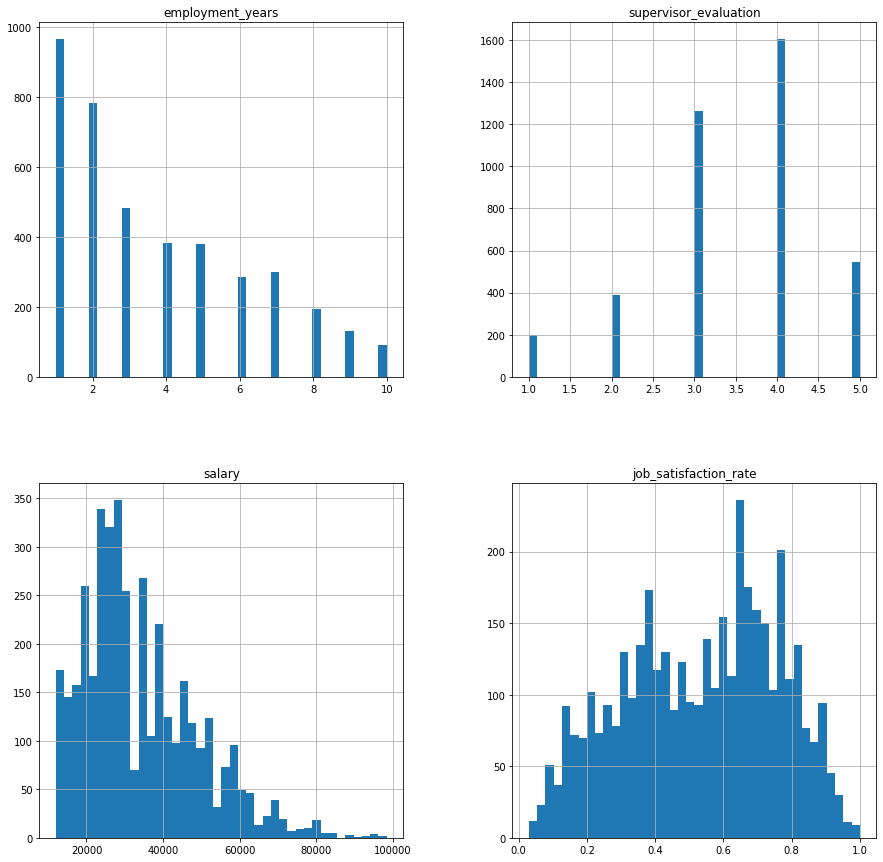

In [37]:
train_job_satisfaction[['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']].hist(figsize=(15, 15), bins = 40);

Видим, что наши данные не распределены нормально: в столбцах 'employment_years' и 'supervisor_evaluation' дискретные распределения, во втором непрерывное.

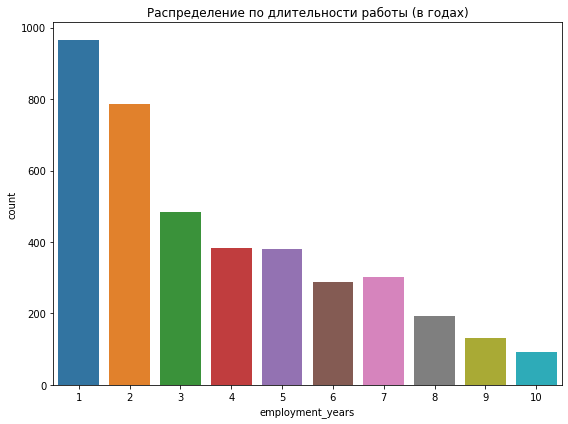

In [38]:

plt.figure(figsize=(8, 6))
sns.countplot(x='employment_years', data=train_job_satisfaction)
plt.title('Распределение по длительности работы (в годах)')
plt.tight_layout()
plt.show()


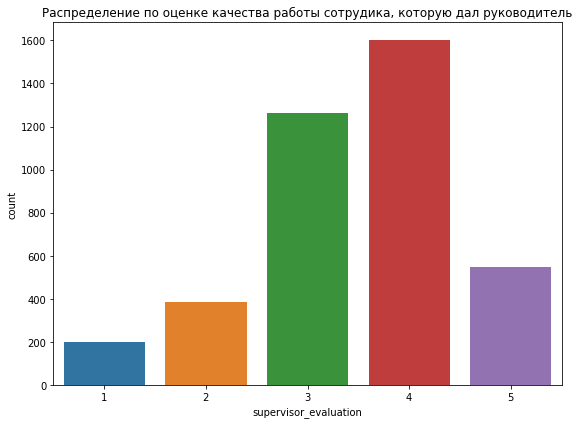

In [39]:

plt.figure(figsize=(8, 6))
sns.countplot(x='supervisor_evaluation', data=train_job_satisfaction)
plt.title('Распределение по оценке качества работы сотрудика, которую дал руководитель')
plt.tight_layout()
plt.show()



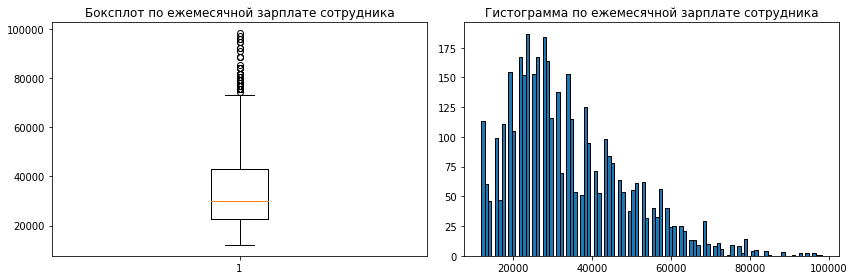

count     4000.000000
mean     33926.700000
std      14900.703838
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      98400.000000
Name: salary, dtype: float64

In [40]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(train_job_satisfaction['salary'])
axes[0].set_title('Боксплот по ежемесячной зарплате сотрудника')

# Второй график — гистограмма
axes[1].hist(train_job_satisfaction['salary'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по ежемесячной зарплате сотрудника')

# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
train_job_satisfaction['salary'].describe()

Видим несколько выбросов, которые также не являются аномальными значениями.

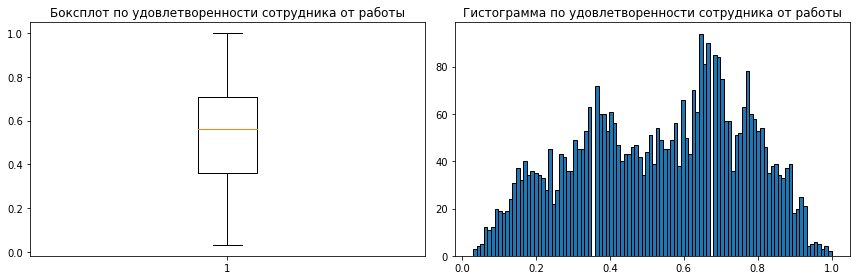

count     4000.000000
mean     33926.700000
std      14900.703838
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      98400.000000
Name: salary, dtype: float64

In [41]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(train_job_satisfaction['job_satisfaction_rate'])
axes[0].set_title('Боксплот по удовлетворенности сотрудника от работы')

# Второй график — гистограмма
axes[1].hist(train_job_satisfaction['job_satisfaction_rate'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по удовлетворенности сотрудника от работы')

# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
train_job_satisfaction['salary'].describe()

Видим, что данные по удовлетворенности не распределены нормально

Посмотрим на статистические данные датасета test_features в сравнении с train_job_satisfaction

In [42]:
test_features.describe().T

,count,mean,std,min,25%,50%,75%,max
id,2000.0,552765.2135,253851.326129,100298.0,339052.0,550793.0,765763.75,999029.0
employment_years,2000.0,3.6665,2.537222,1.0,1.0,3.0,6.00,10.0
supervisor_evaluation,2000.0,3.5265,0.996892,1.0,3.0,4.0,4.00,5.0
salary,2000.0,34066.8000,15398.436729,12000.0,22800.0,30000.0,43200.00,96000.0


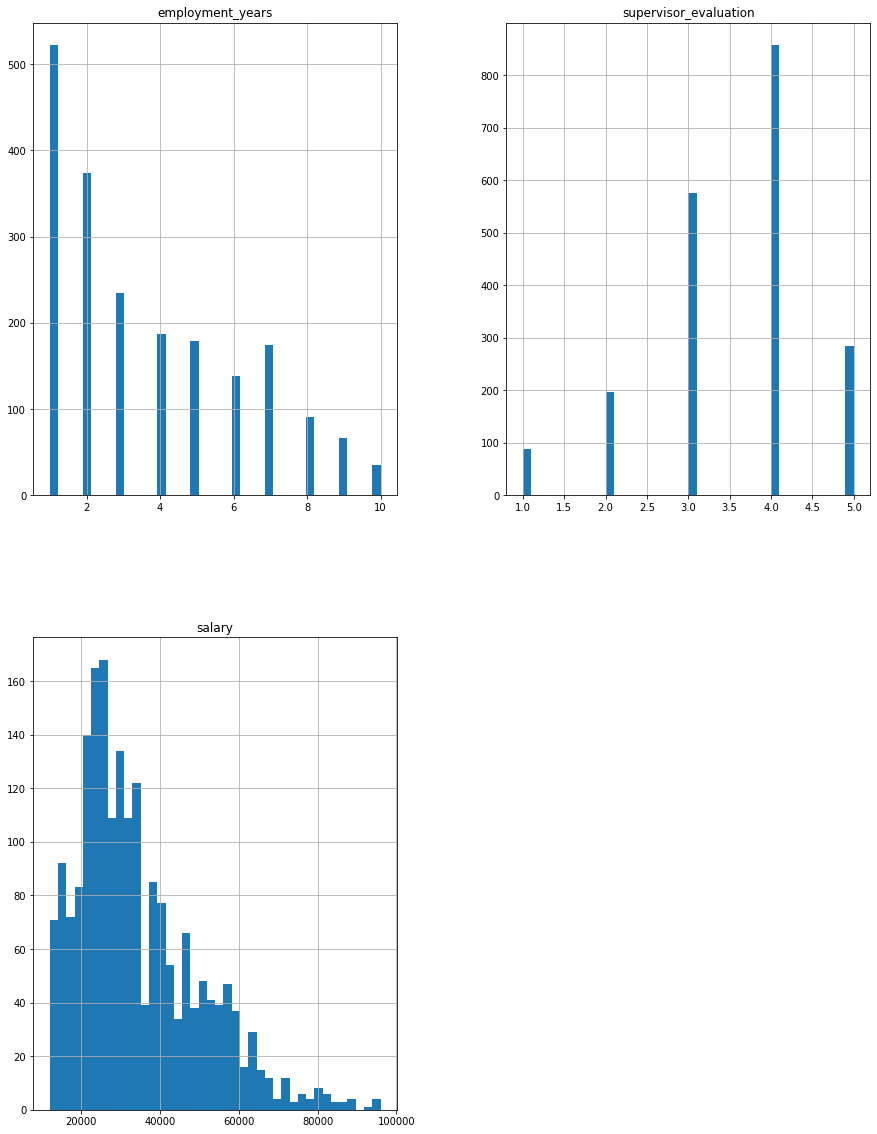

In [43]:
test_features[['employment_years', 'supervisor_evaluation', 'salary']].hist(figsize=(15, 20), bins = 40);

В данном случае, как и по тренировочной выборке, мы видим, что наши данные не распределены нормально.

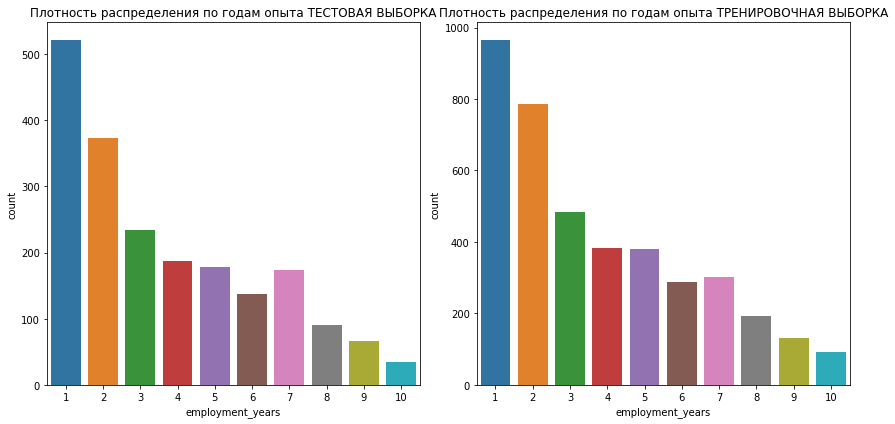

In [44]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# boxplot тестовая выборка 
sns.countplot(x='employment_years', data=test_features, ax = axes[0])  
axes[0].set_title('Плотность распределения по годам опыта ТЕСТОВАЯ ВЫБОРКА')

#  boxplot тренировочная выборка 
sns.countplot(x='employment_years', data=train_job_satisfaction, ax = axes[1]) 
axes[1].set_title('Плотность распределения по годам опыта ТРЕНИРОВОЧНАЯ ВЫБОРКА')

# Показываем оба графика
plt.tight_layout()
plt.show()

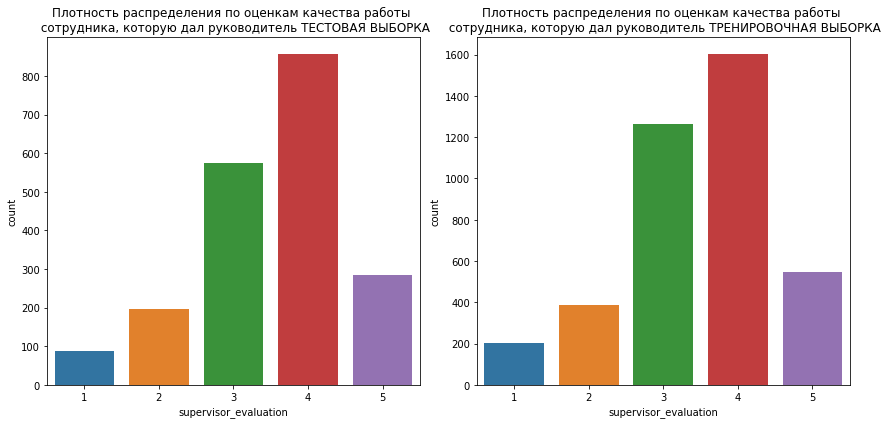

In [45]:

# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# boxplot тестовая выборка 
sns.countplot(x='supervisor_evaluation', data=test_features, ax = axes[0])  
axes[0].set_title('Плотность распределения по оценкам качества работы \n сотрудника, которую дал руководитель ТЕСТОВАЯ ВЫБОРКА')

#  boxplot тренировочная выборка 
sns.countplot(x='supervisor_evaluation', data=train_job_satisfaction, ax = axes[1]) 
axes[1].set_title('Плотность распределения по оценкам качества работы \n сотрудника, которую дал руководитель ТРЕНИРОВОЧНАЯ ВЫБОРКА')

# Показываем оба графика
plt.tight_layout()
plt.show()

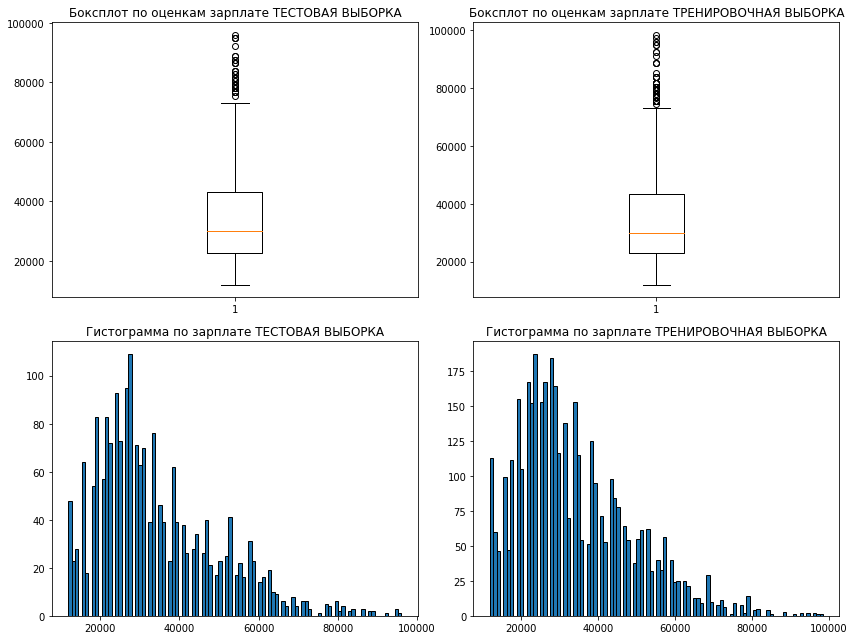

,salary_evaluation_test,salary_evaluation_train
count,2000.000000,4000.000000
mean,34066.800000,33926.700000
std,15398.436729,14900.703838
min,12000.000000,12000.000000
25%,22800.000000,22800.000000
50%,30000.000000,30000.000000
75%,43200.000000,43200.000000
max,96000.000000,98400.000000


In [46]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# boxplot тестовая выборка 
axes[0, 0].boxplot(test_features['salary'])
axes[0, 0].set_title('Боксплот по оценкам зарплате ТЕСТОВАЯ ВЫБОРКА')

#  boxplot тренировочная выборка 
axes[0, 1].boxplot(train_job_satisfaction['salary'])
axes[0, 1].set_title('Боксплот по оценкам зарплате ТРЕНИРОВОЧНАЯ ВЫБОРКА')

# гистограмма тестовая выборка 
axes[1,0].hist(test_features['salary'], bins=100, edgecolor='black')
axes[1,0].set_title('Гистограмма по зарплате ТЕСТОВАЯ ВЫБОРКА')

# гистограмма тренировочная выборка 
axes[1,1].hist(train_job_satisfaction['salary'], bins=100, edgecolor='black')
axes[1,1].set_title('Гистограмма по зарплате ТРЕНИРОВОЧНАЯ ВЫБОРКА')

# Показываем оба графика
plt.tight_layout()
plt.show()

desc_test = test_features['salary'].describe()
desc_train = train_job_satisfaction['salary'].describe()

# Объединяем их в один DataFrame, например, по столбцам
summary_df = pd.DataFrame({
    'salary_evaluation_test': desc_test,
    'salary_evaluation_train': desc_train
})

summary_df

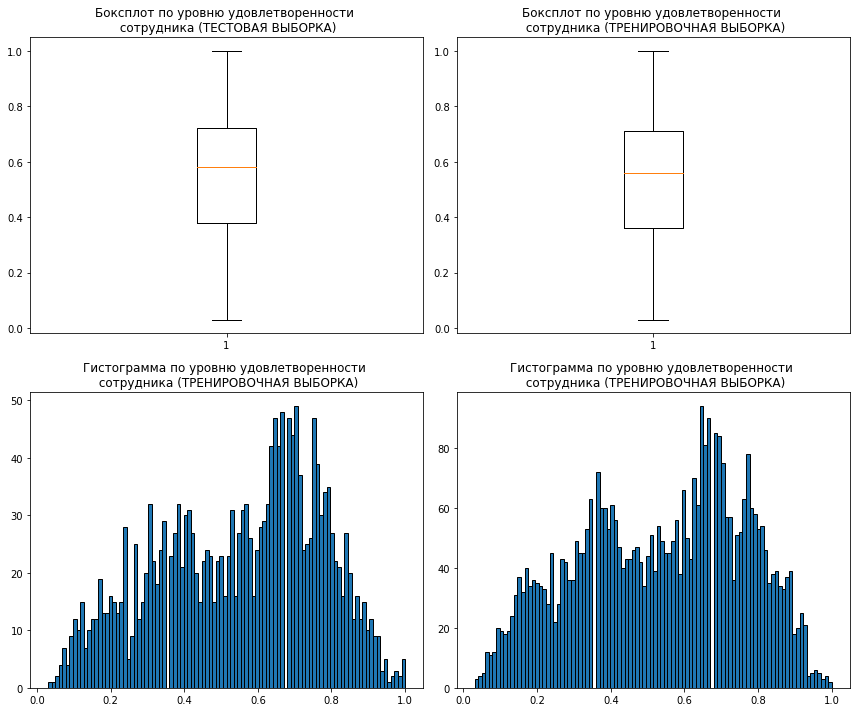

,job_satisfaction_rate_test,job_satisfaction_rate_train
count,2000.00000,4000.000000
mean,0.54878,0.533995
std,0.22011,0.225327
min,0.03000,0.030000
25%,0.38000,0.360000
50%,0.58000,0.560000
75%,0.72000,0.710000
max,1.00000,1.000000


In [47]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Первый график — boxplot
axes[0, 0].boxplot(test_target_job_satisfaction_rate['job_satisfaction_rate'])
axes[0, 0].set_title('Боксплот по уровню удовлетворенности \n сотрудника (ТЕСТОВАЯ ВЫБОРКА)')

#  boxplot тренировочная выборка 
axes[0, 1].boxplot(train_job_satisfaction['job_satisfaction_rate'])
axes[0, 1].set_title('Боксплот по уровню удовлетворенности \n сотрудника (ТРЕНИРОВОЧНАЯ ВЫБОРКА)')

# Второй график — гистограмма
axes[1, 0].hist(test_target_job_satisfaction_rate['job_satisfaction_rate'], bins=100, edgecolor='black')
axes[1, 0].set_title('Гистограмма по уровню удовлетворенности \n сотрудника (ТРЕНИРОВОЧНАЯ ВЫБОРКА)')

# Второй график — гистограмма
axes[1, 1].hist(train_job_satisfaction['job_satisfaction_rate'], bins=100, edgecolor='black')
axes[1, 1].set_title('Гистограмма по уровню удовлетворенности \n сотрудника (ТРЕНИРОВОЧНАЯ ВЫБОРКА)')

# Показываем оба графика
plt.tight_layout()
plt.show()

desc_test = test_target_job_satisfaction_rate['job_satisfaction_rate'].describe()
desc_train = train_job_satisfaction['job_satisfaction_rate'].describe()

# Объединяем их в один DataFrame, например, по столбцам
summary_df = pd.DataFrame({
    'job_satisfaction_rate_test': desc_test,
    'job_satisfaction_rate_train': desc_train
})

summary_df

Уровень удовлетворенности также не распределен нормально.

В целом при сравнении данных датасета тренировочной выборки, а также данных датасетов входных и целевого признаков тестовой выборки видим, что признаки в тренировочной и тестовой выборках распределены похожим образом.

**Шаг 4. Корреляционный анализ**

In [48]:
result_for_phik_train = train_job_satisfaction.drop(columns=['id'])

In [49]:
phik_corr_train = phik_matrix(result_for_phik_train, interval_cols=['salary', 'job_satisfaction_rate'])

In [50]:
phik_corr_train

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
dept,1.000000,0.000000,0.016509,0.037853,0.000000,0.000000,0.105495,0.282265,0.082086
level,0.000000,1.000000,0.419114,0.682773,0.101613,0.000000,0.000000,0.717630,0.080620
workload,0.016509,0.419114,1.000000,0.181941,0.058663,0.000000,0.037023,0.788820,0.056128
employment_years,0.037853,0.682773,0.181941,1.000000,0.183579,0.056808,0.000000,0.483419,0.325603
last_year_promo,0.000000,0.101613,0.058663,0.183579,1.000000,0.000000,0.013681,0.215025,0.190803
last_year_violations,0.000000,0.000000,0.000000,0.056808,0.000000,1.000000,0.182042,0.010078,0.560348
supervisor_evaluation,0.105495,0.000000,0.037023,0.000000,0.013681,0.182042,1.000000,0.000000,0.764364
salary,0.282265,0.717630,0.788820,0.483419,0.215025,0.010078,0.000000,1.000000,0.165830
job_satisfaction_rate,0.082086,0.080620,0.056128,0.325603,0.190803,0.560348,0.764364,0.165830,1.000000


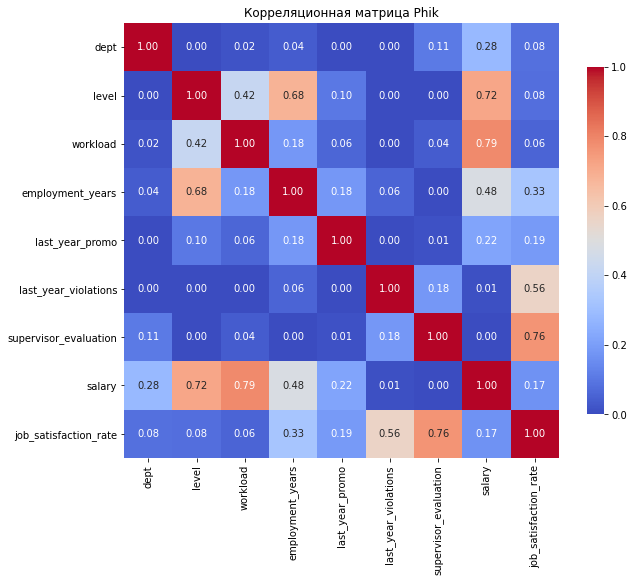

In [51]:
plt.figure(figsize=(10, 8))  
sns.heatmap(phik_corr_train, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title('Корреляционная матрица Phik')
plt.show()


Видим, что сильнее всего целевой признак связан  с supervisor_evaluation. Также  значимая связь имеется с last_year_violations. С employment_years связь умеренная. С остальными - слабая. Мультиколлинеарности нет.

In [52]:
test = pd.merge(test_features, test_target_job_satisfaction_rate, on='id', how='inner') 

In [53]:
result_for_phik_test = test.drop(columns=['id'])

In [54]:
phik_corr_test = phik_matrix(result_for_phik_test, interval_cols=['salary', 'job_satisfaction_rate'])

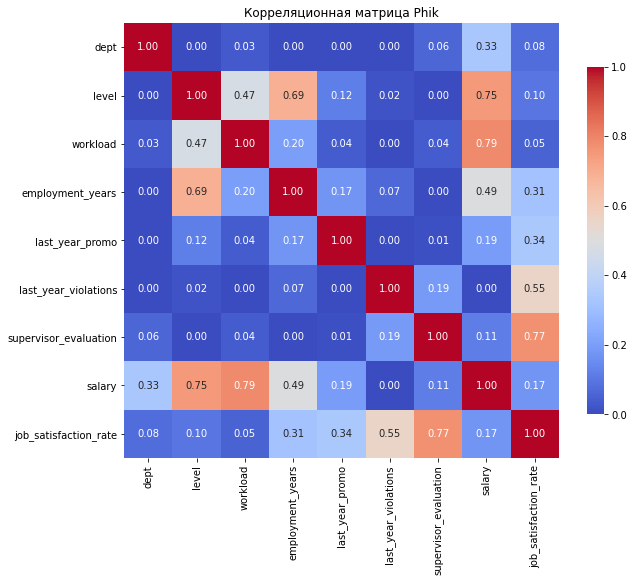

In [55]:
plt.figure(figsize=(10, 8))  
sns.heatmap(phik_corr_test, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title('Корреляционная матрица Phik')
plt.show()


Видим, что существенных различий в связи таргета и входящийх признаков в тестовой выборке по сравнению с тренировочной нет, оценка модели, которую получим на тестовой выборке, будет корректной.

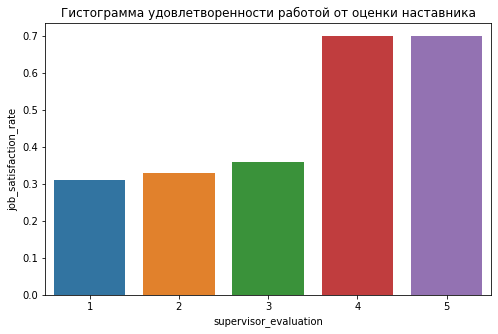

In [56]:
plt.figure(figsize=(8, 5))  
median_values = train_job_satisfaction.groupby('supervisor_evaluation')['job_satisfaction_rate'].median().reset_index()
sns.barplot(x='supervisor_evaluation', y='job_satisfaction_rate', data=median_values)
plt.title('Гистограмма удовлетворенности работой от оценки наставника')
plt.show()

Видим, что в среднем, если сотрудника его руководитель оценивает низко или средне, то и сотрудник работой не удовлетворен, напротив если руководитель оценивает сотрудника хорошо и оень хорошо, то тут средний уровень удовлетворенности сразу вдвое вырастает.

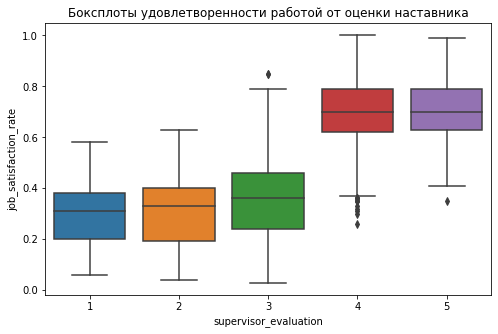

In [57]:
plt.figure(figsize=(8, 5))  
sns.boxplot(x='supervisor_evaluation', y='job_satisfaction_rate', data=train_job_satisfaction)
plt.title('Боксплоты удовлетворенности работой от оценки наставника')
plt.show()

Здесь видим, что есть опеределенное количество "троечников", чей уровень удовлетворенности довольно высок (между 0.7 и 0.8)

Теперь посмотрим на распределение last_year_violations в контексте удовлетворенности сотрудников от работы

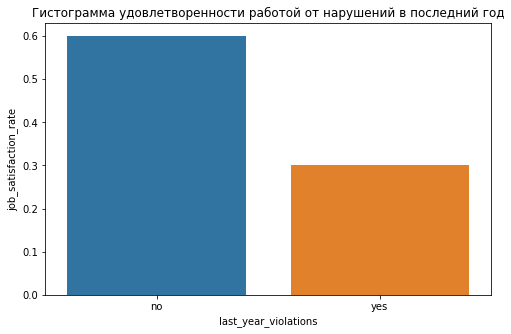

In [58]:
plt.figure(figsize=(8, 5))  
median_values = train_job_satisfaction.groupby('last_year_violations')['job_satisfaction_rate'].median().reset_index()
sns.barplot(x='last_year_violations', y='job_satisfaction_rate', data=median_values)
plt.title('Гистограмма удовлетворенности работой от нарушений в последний год')
plt.show()

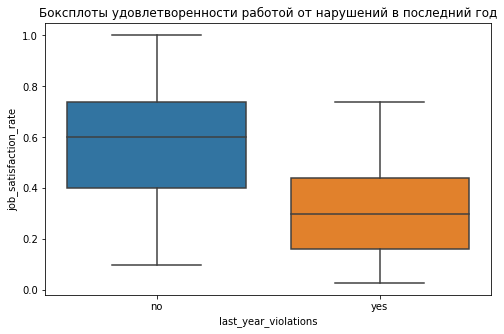

In [59]:
plt.figure(figsize=(8, 5))  
sns.boxplot(x='last_year_violations', y='job_satisfaction_rate', data=train_job_satisfaction)
plt.title('Боксплоты удовлетворенности работой от нарушений в последний год')
plt.show()

Видим, что в среднем те сотрудники, у которых не было нарушений трудового договора за последний год, оценивают в два раза выше свою работу (уровень 0.6 vs 0.3).

Теперь взглянем на связь таргета с employment_years

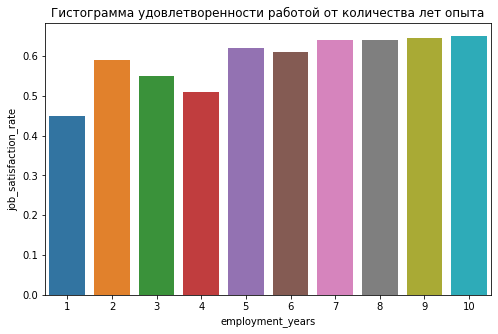

In [60]:
plt.figure(figsize=(8, 5))  
median_values = train_job_satisfaction.groupby('employment_years')['job_satisfaction_rate'].median().reset_index()
sns.barplot(x='employment_years', y='job_satisfaction_rate', data=median_values)
plt.title('Гистограмма удовлетворенности работой от количества лет опыта')


plt.show()

Видим, что чем дольше сотрудник остается в компании, тем выше в среднем уровень его удовлетворенности

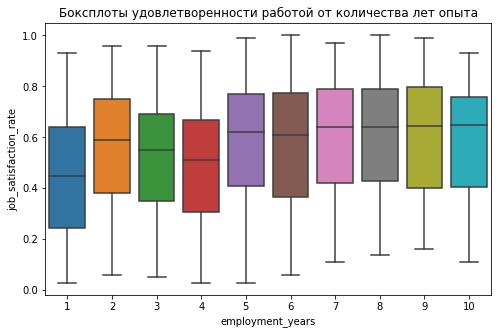

In [61]:
plt.figure(figsize=(8, 5))  
sns.boxplot(x='employment_years', y='job_satisfaction_rate', data=train_job_satisfaction)
plt.title('Боксплоты удовлетворенности работой от количества лет опыта')

plt.show()

**Шаг 5. Использование пайплайнов**

In [62]:
RANDOM_STATE = 42


In [63]:
test_features

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800
...,...,...,...,...,...,...,...,...,...
1995,393147,marketing,junior,low,3,no,no,3,20400
1996,109582,technology,middle,low,3,no,no,2,21600
1997,305653,technology,junior,low,1,no,no,3,14400
1998,160233,technology,middle,low,8,no,no,1,32400


In [64]:
result_for_phik_train.duplicated().sum()

245

Видим, что после удаления столбца id, у нас появилось 245 идентичных записей. Удалим их.

In [65]:
result_for_phik_train.drop_duplicates(inplace=True)

In [66]:
result_for_phik_train.duplicated().sum()

0

In [67]:
X_train = result_for_phik_train.drop('job_satisfaction_rate', axis=1)
y_train = result_for_phik_train['job_satisfaction_rate']

Прежде чем кодировать признаки, выведем значения порядковых категориальных признаков


In [68]:
result_for_phik_train['level'].unique() 

array(['junior', 'middle', 'sinior', nan], dtype=object)

In [69]:
result_for_phik_train['workload'].unique()

array(['medium', 'high', 'low'], dtype=object)

In [70]:
# создаём списки с названиями признаков
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']
ord_columns = ['level', 'workload']
num_columns = ['employment_years', 'supervisor_evaluation', 'salary']

# создаём пайплайн для подготовки признаков с помощью OHE из списка ohe_columns
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False))]
    )

# создаём пайплайн для подготовки признаков с помощью ORD из списка ord_columns
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ('ord',  OrdinalEncoder(
                categories= [
                    ['junior', 'middle', 'sinior', np.nan],
                    ['low', 'medium', 'high'],
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)



Так как модели, которые мы будем использовать реализуют разные типы предсказаниий, то нам нужны два отдельных пайплайна
    Дерево решений — модель для регрессии, которая использует одни гиперпараметры и структуру.
    Линейная регрессия — тоже регрессор, но с совсем другой внутренней реализацией и гиперпараметрами.


In [71]:
#гипер-параметры для дерева решений
param_grid_tree = [
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 100, 2),
        'models__max_features': range(2, 100, 2),
        'models__min_samples_split': [2, 5, 10, 20, 30, 40, 50, 100, 150],
        'models__min_samples_leaf': [1, 2, 4, 8, 10, 12],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
        },
]

In [72]:
#гипер-параметры для линейной регрессии
param_grid_lr = [
    {
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough'],
        'models': [LinearRegression()],
    }
]

In [73]:
def smape(y_true, y_pred):
     
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    # Чтобы избежать деления на ноль, добавим небольшой epsilon
    epsilon = 1e-8
    denominator = np.where(denominator == 0, epsilon, denominator)

    smape_value = np.mean(np.abs(y_true - y_pred) / denominator) * 100
    return smape_value

In [74]:
smape_scorer = make_scorer(smape, greater_is_better=False)

В нашем случае, так как для нашей метрики SMAPE greater_is_better=False, то search.best_score_ — это отрицательное значение, поэтому выводить необходимо "-search.best_score_" 

In [75]:
#пайплайн для дерева решений

pipeline_tree = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

search_tree = RandomizedSearchCV(
    pipeline_tree,
    param_distributions=param_grid_tree,
    n_iter=50,
    cv=5,
    scoring=smape_scorer,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

search_tree.fit(X_train, y_train)
print(f"SMAPE на кросс-валидации: {-search_tree.best_score_:.2f}%")

SMAPE на кросс-валидации: 15.24%


In [76]:
pipeline_lr = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LinearRegression())
])

search_lr = RandomizedSearchCV(
    pipeline_lr,
    param_distributions=param_grid_lr,
    n_iter=50,
    cv=5,
    scoring=smape_scorer,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

search_lr.fit(X_train, y_train)
print(f"SMAPE на кросс-валидации: {-search_lr.best_score_:.2f}%")

/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_search.py:306: UserWarning: The total space of parameters 3 is smaller than n_iter=50. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


SMAPE на кросс-валидации: 25.01%


Теперь посчитаем метрику на тестовой выборке. Будем использовать модель , которая показала бОльшее значение метрики на валидационной выборке. Требуется проверить, что y_test соответствует предсказанным данным y_test_pred, например, следует проверить что индексы в y_test соответствуют индексам в X_test (по этим признакам делаются предсказания на тесте), иначе получится, что в метрике будут сверяться разные объекты и результаты будут случайными. 

In [77]:
test_merged = test_target_job_satisfaction_rate.merge(test_features, how='right', on='id')

In [78]:
test_features.drop('id', axis=1, inplace=True)

In [81]:
dummy_model = DummyRegressor(strategy='mean')  # предсказывает среднее значение
dummy_model.fit(X_train, y_train)

DummyRegressor()

In [82]:
dummy_pred = dummy_model.predict(test_merged.drop('job_satisfaction_rate',  axis=1, inplace=False))

In [83]:
print(f"SMAPE для константной модели: {smape(test_merged['job_satisfaction_rate'], dummy_pred):.2f}%")


best_model = search_tree.best_estimator_
test_pred = best_model.predict(test_merged.drop('job_satisfaction_rate',  axis=1, inplace=False))
print(f"SMAPE на тестовой выборке: {smape(test_merged['job_satisfaction_rate'], test_pred):.2f}%")

SMAPE для константной модели: 38.26%
SMAPE на тестовой выборке: 13.93%


Таким образом, видим, что целесообразность модели, созданной в ходе решения задачи, имеется.

***Вывод по Задаче 1: При решении задачи предсказания уровня удовлетворенности сотрудников работой мы сравнили две модели с помощью перебора иснтрументом RandomSearchCV гиперпараметров моделей: DecisionTreeRegressoe, LinearRegression. Лучшие результаты по выбранной нами метрике SMAPE показала модель DecisionTreeRegressor(max_depth=96, max_features=24, min_samples_split=5), на тестовой выборке получили значение 13.93%. При этом наша модель прошла проверку сравнением с DummyRegressorю.***

***Задача 2***

Описание задачи: целевой признак отличается это quit — увольнение сотрудника из компании. Входные признаки мы будем исползовать те же, что и в первой задаче

***Шаг 1 Загрузка данных***

In [84]:
train_quit = pd.read_csv('/datasets/train_quit.csv')

In [85]:
train_quit

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no
...,...,...,...,...,...,...,...,...,...,...
3995,588809,sales,junior,medium,4,no,no,3,26400,no
3996,672059,sales,middle,high,9,no,no,4,52800,no
3997,536432,purchasing,junior,low,2,no,yes,4,12000,yes
3998,692133,purchasing,middle,medium,2,no,no,4,33600,no


In [86]:
test_target_quit  = pd.read_csv('/datasets/test_target_quit.csv')

In [87]:
test_target_quit

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes
...,...,...
1995,836109,yes
1996,180999,yes
1997,746018,no
1998,247658,no


In [88]:
test_features_2 = pd.read_csv('/datasets/test_features.csv')

***Промужуточынй вывод по шагу 1: видим, что данные в датасетах соответствуют описанию***

***Шаг 2 Предобработка данных***

Проверим данные на пропуски

In [89]:
train_quit.isnull().sum()

id                       0
dept                     0
level                    0
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
quit                     0
dtype: int64

In [90]:
test_features_2.isnull().sum()

id                       0
dept                     2
level                    1
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
dtype: int64

Помним по первой задаче, что в датасете с тестовыми признаками были 3 пропуска, аналогичным образом заполним их в пайплайне в дальнейшем

In [91]:
test_target_quit.isnull().sum()

id      0
quit    0
dtype: int64

Теперь проверим на полные дубликаты

In [92]:
train_quit.duplicated().sum()

0

In [93]:
test_features_2.duplicated().sum()

0

In [94]:
test_target_quit.duplicated().sum()

0

Полные дубликаты отсутствуют

Теперь посмотрим на уникальные значения категориальных столбцов, чтобы устранить некорректные значения (при наличии)


In [95]:
train_quit['dept'].unique()

array(['sales', 'purchasing', 'marketing', 'technology', 'hr'],
      dtype=object)

In [96]:
train_quit['level'].unique()

array(['middle', 'junior', 'sinior'], dtype=object)

In [97]:
train_quit['workload'].unique()

array(['high', 'medium', 'low'], dtype=object)

In [98]:
train_quit['last_year_promo'].unique()

array(['no', 'yes'], dtype=object)

In [99]:
train_quit['last_year_violations'].unique()

array(['no', 'yes'], dtype=object)

In [100]:
train_quit['quit'].unique()

array(['no', 'yes'], dtype=object)

In [101]:
test_target_quit['quit'].unique()

array(['yes', 'no'], dtype=object)

Помним, что в ходе решения первой задачи мы обнаружили в датасете с тестовыми признаками еще по одному пропущенному значению (' ') workload и dept.

Посмотрим теперь на типы данных

In [102]:
train_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


In [103]:
test_target_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


Видим, что типы данных соответствуют содержанию датасетов

 ***Шаг 3.1 Исследовательский анализ***

In [104]:
train_quit.describe().T

,count,mean,std,min,25%,50%,75%,max
id,4000.0,552099.28375,260158.031387,100222.0,327785.75,546673.0,781497.75,999915.0
employment_years,4000.0,3.70150,2.541852,1.0,2.00,3.0,6.00,10.0
supervisor_evaluation,4000.0,3.47475,1.004049,1.0,3.00,4.0,4.00,5.0
salary,4000.0,33805.80000,15152.415163,12000.0,22800.00,30000.0,43200.00,96000.0


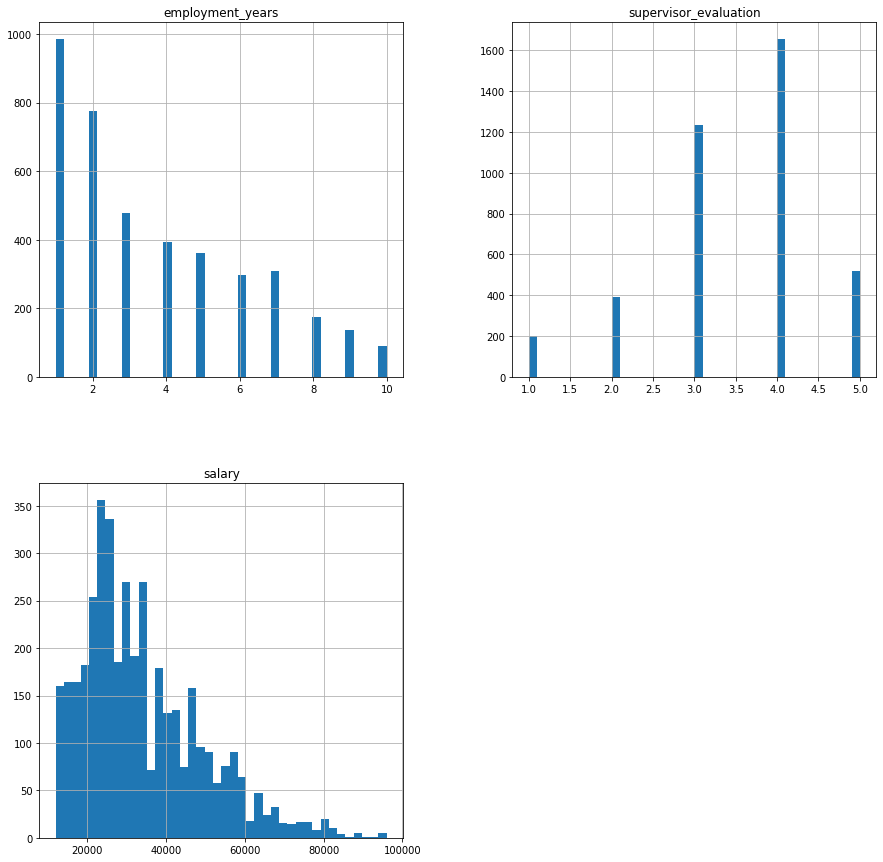

In [105]:
train_quit[['employment_years', 'supervisor_evaluation', 'salary']].hist(figsize=(15, 15), bins = 40);

Данные распределены похожим образом в сравнении с тренировочной выборкой первой задачи

In [106]:
pd.DataFrame({
    'Количество': train_quit['quit'].value_counts(),
    'Процент %': train_quit['quit'].value_counts(normalize=True)
})


,Количество,Процент %
no,2872,0.718
yes,1128,0.282


Видим, что 28% всех записей по датасету тренировочной выборки составляют записи по уволившимся сотрудникам.


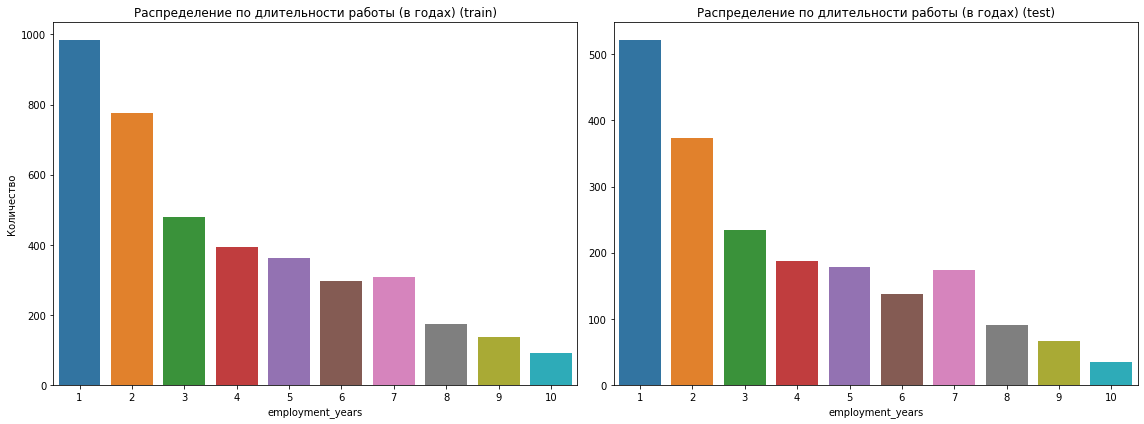

In [107]:
# Создаем фигуру с двумя подграфиками по горизонтали
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Первый график
sns.countplot(x='employment_years', data=train_quit, ax=axes[0])
axes[0].set_title('Распределение по длительности работы (в годах) (train)')
axes[0].set_xlabel('employment_years')
axes[0].set_ylabel('Количество')

# Второй график
sns.countplot(x='employment_years', data=test_features_2, ax=axes[1])
axes[1].set_title('Распределение по длительности работы (в годах) (test)')
axes[1].set_xlabel('employment_years')
axes[1].set_ylabel('')

# Чтобы подгонять layout
plt.tight_layout()
plt.show()

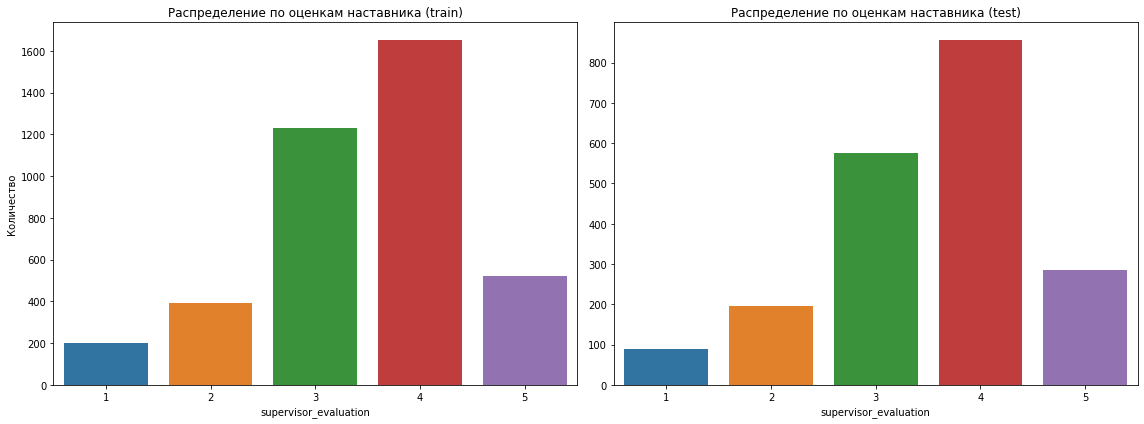

In [108]:
# Создаем фигуру с двумя подграфиками по горизонтали
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Первый график
sns.countplot(x='supervisor_evaluation', data=train_quit, ax=axes[0])
axes[0].set_title('Распределение по оценкам наставника (train)')
axes[0].set_xlabel('supervisor_evaluation')
axes[0].set_ylabel('Количество')

# Второй график
sns.countplot(x='supervisor_evaluation', data=test_features_2, ax=axes[1])
axes[1].set_title('Распределение по оценкам наставника (test)')
axes[1].set_xlabel('supervisor_evaluation')
axes[1].set_ylabel('')

# Чтобы подгонять layout
plt.tight_layout()
plt.show()

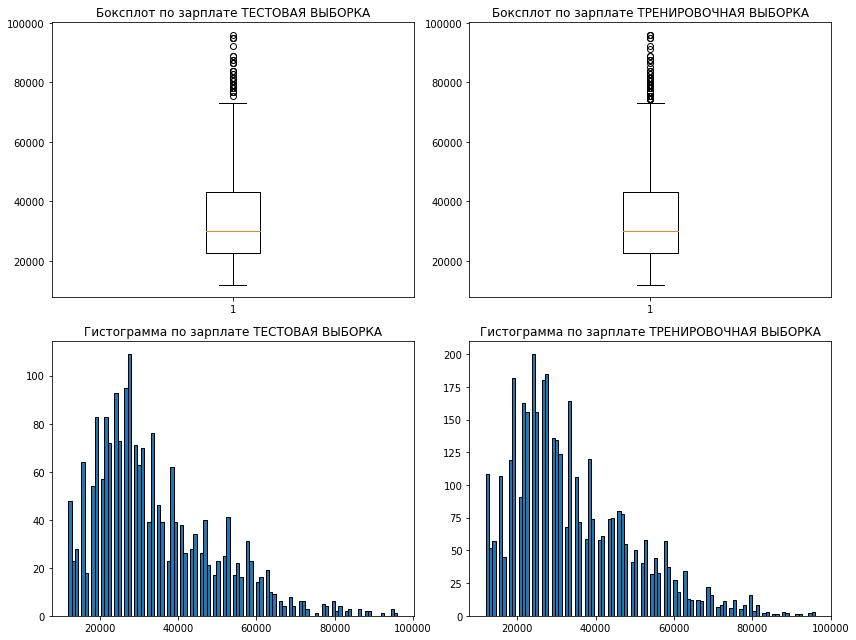

,salary_evaluation_test,salary_evaluation_train
count,2000.000000,4000.000000
mean,34066.800000,33805.800000
std,15398.436729,15152.415163
min,12000.000000,12000.000000
25%,22800.000000,22800.000000
50%,30000.000000,30000.000000
75%,43200.000000,43200.000000
max,96000.000000,96000.000000


In [109]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# boxplot тестовая выборка 
axes[0, 0].boxplot(test_features_2['salary'])
axes[0, 0].set_title('Боксплот по зарплате ТЕСТОВАЯ ВЫБОРКА')

#  boxplot тренировочная выборка 
axes[0, 1].boxplot(train_quit['salary'])
axes[0, 1].set_title('Боксплот по зарплате ТРЕНИРОВОЧНАЯ ВЫБОРКА')

# гистограмма тестовая выборка 
axes[1,0].hist(test_features_2['salary'], bins=100, edgecolor='black')
axes[1,0].set_title('Гистограмма по зарплате ТЕСТОВАЯ ВЫБОРКА')

# гистограмма тренировочная выборка 
axes[1,1].hist(train_quit['salary'], bins=100, edgecolor='black')
axes[1,1].set_title('Гистограмма по зарплате ТРЕНИРОВОЧНАЯ ВЫБОРКА')

# Показываем оба графика
plt.tight_layout()
plt.show()

desc_test = test_features_2['salary'].describe()
desc_train = train_quit['salary'].describe()

# Объединяем их в один DataFrame, например, по столбцам
summary_df = pd.DataFrame({
    'salary_evaluation_test': desc_test,
    'salary_evaluation_train': desc_train
})

summary_df

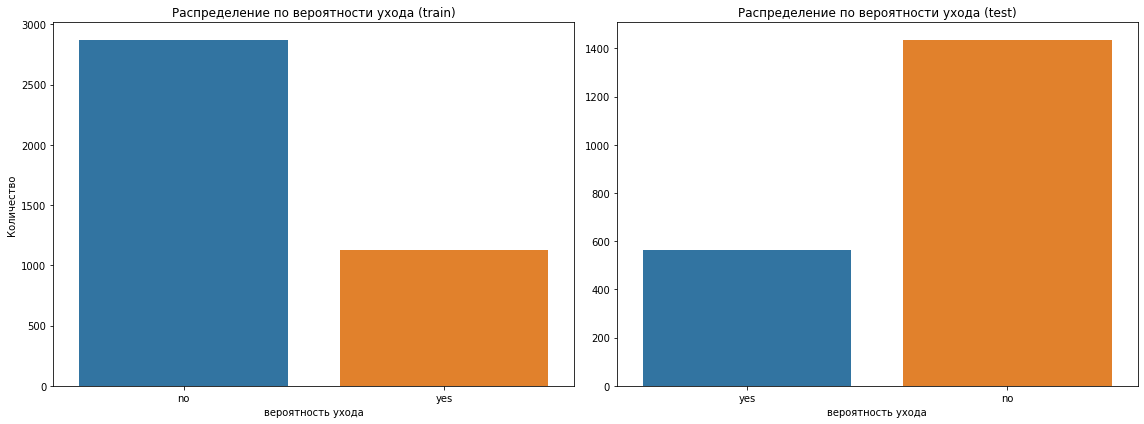

In [110]:
# Создаем фигуру с двумя подграфиками по горизонтали
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Первый график
sns.countplot(x='quit', data=train_quit, ax=axes[0])
axes[0].set_title('Распределение по вероятности ухода (train)')
axes[0].set_xlabel('вероятность ухода')
axes[0].set_ylabel('Количество')

# Второй график
sns.countplot(x='quit', data=test_target_quit, ax=axes[1])
axes[1].set_title('Распределение по вероятности ухода (test)')
axes[1].set_xlabel('вероятность ухода')
axes[1].set_ylabel('')

# Чтобы подгонять layout
plt.tight_layout()
plt.show()

Видим, что по всем  четырем переменным (включая целевой) в тренировочной и тестовой выборках значения распределены похожим образом

Построим матрицу для тренировочной матрицы

In [111]:
result_for_phik_train_2 = train_quit.drop(columns=['id'])

In [112]:
phik_corr_train_2 = phik_matrix(result_for_phik_train_2, interval_cols='salary')

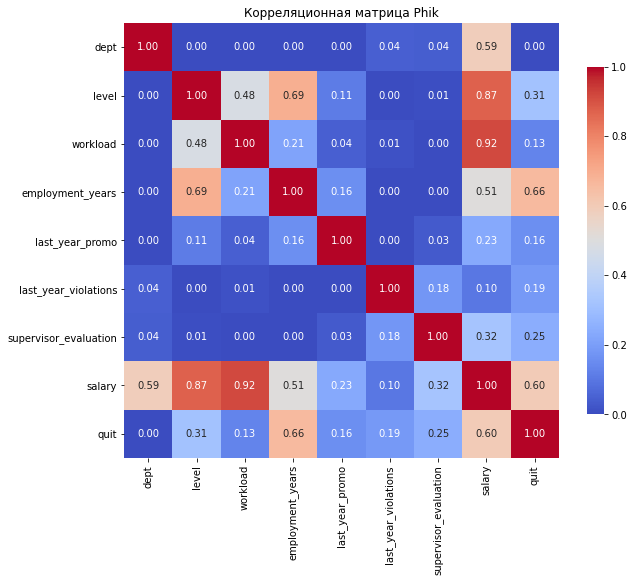

In [113]:
plt.figure(figsize=(10, 8))  
sns.heatmap(phik_corr_train_2, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title('Корреляционная матрица Phik')
plt.show()

***Видим наличие мультиколлинеарности между workload и salary и между level и salary***

Теперь построим корреляционную матрицу  для тестовой выборки

In [114]:
test_2 = pd.merge(test_features_2, test_target_quit, on='id', how='inner') 

In [115]:
result_for_phik_test_2 = test_2.drop(columns=['id'])                                 

In [116]:
phik_corr_test_2 = phik_matrix(result_for_phik_test_2, interval_cols=['salary'])

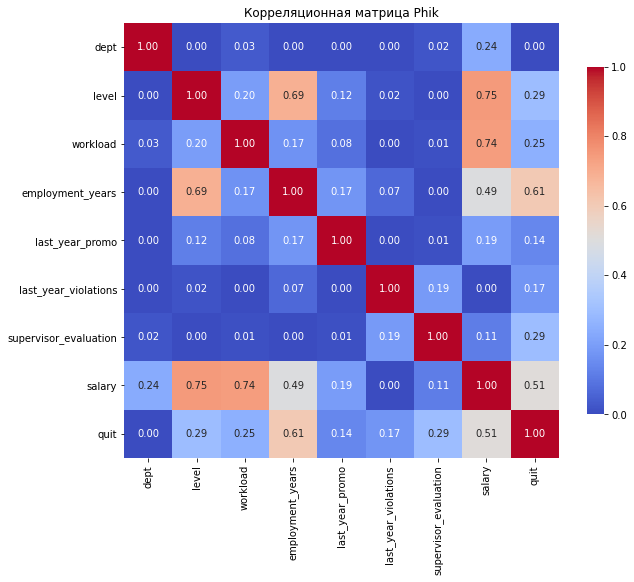

In [117]:
plt.figure(figsize=(10, 8))
sns.heatmap(phik_corr_test_2, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title('Корреляционная матрица Phik')
plt.show()

В целом видим, что связи целевой переменной и входных признаков в тренировочной и тестовых выборках похожи

 ***Шаг 3.2 Портрет уволившегося сотрудника***

In [118]:
positive_class_data = train_quit[train_quit['quit'] == 'yes']

In [119]:
employment_years_norm = positive_class_data['employment_years'].value_counts(normalize=True)

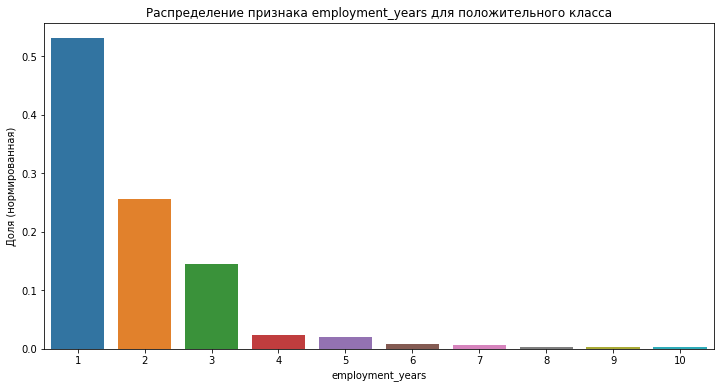

In [120]:
# Создаем DataFrame из Series для удобства построения
plot_data = employment_years_norm.reset_index()
plot_data.columns = ['employment_years', 'доля']

# Строим barplot
plt.figure(figsize=(12, 6))
sns.barplot(x='employment_years', y='доля', data=plot_data)
plt.ylabel('Доля (нормированная)')
plt.title('Распределение признака employment_years для положительного класса')
plt.show()

Видим, что более половины уволившихся сотрудников работают около года

In [121]:
dept_norm = positive_class_data['dept'].value_counts(normalize=True)

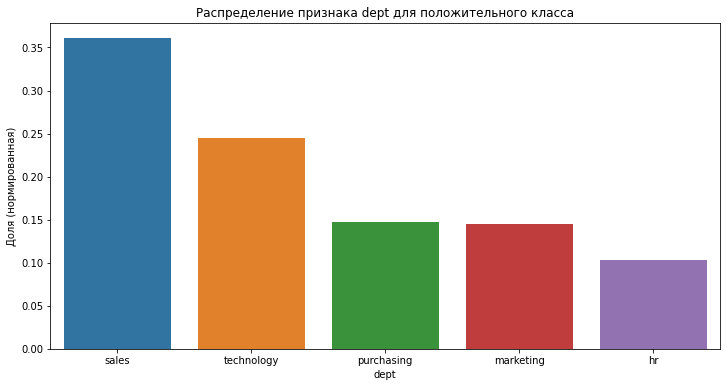

In [122]:
# Создаем DataFrame из Series для удобства построения
plot_data = dept_norm.reset_index()
plot_data.columns = ['dept', 'доля']

# Строим barplot
plt.figure(figsize=(12, 6))
sns.barplot(x='dept', y='доля', data=plot_data)
plt.ylabel('Доля (нормированная)')
plt.title('Распределение признака dept для положительного класса')
plt.show()

Видим, что чуть больше трети сотрудников увольняются из отдела продаж

In [123]:
level_norm = positive_class_data['level'].value_counts(normalize=True)

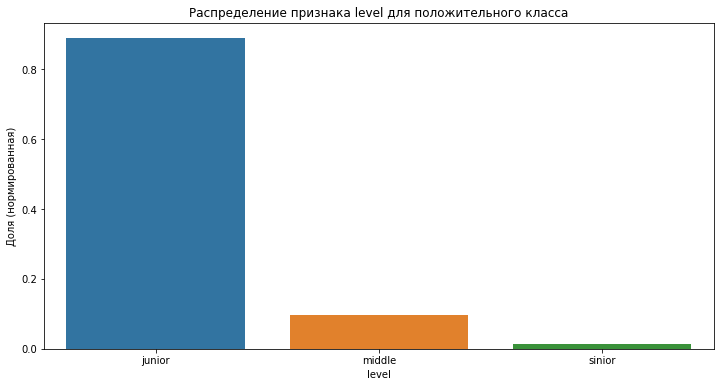

In [124]:
# Создаем DataFrame из Series для удобства построения
plot_data = level_norm.reset_index()
plot_data.columns = ['level', 'доля']

# Строим barplot
plt.figure(figsize=(12, 6))
sns.barplot(x='level', y='доля', data=plot_data)
plt.ylabel('Доля (нормированная)')
plt.title('Распределение признака level для положительного класса')
plt.show()

Видим, что абсолютное большинство уволившихся занимали джуниор-позиции.

In [125]:
workload_norm = positive_class_data['workload'].value_counts(normalize=True)

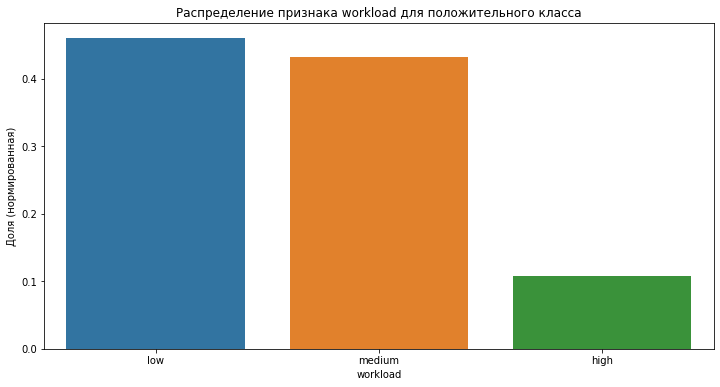

In [126]:
# Создаем DataFrame из Series для удобства построения
plot_data = workload_norm.reset_index()
plot_data.columns = ['workload', 'доля']

# Строим barplot
plt.figure(figsize=(12, 6))
sns.barplot(x='workload', y='доля', data=plot_data)
plt.ylabel('Доля (нормированная)')
plt.title('Распределение признака workload для положительного класса')
plt.show()

Видим, что уволившихся со средним и низким уровнем нагрузки (вместе около 90%) примероно поровну, но все же больше с низким уровнем.

In [127]:
last_year_promo_norm = positive_class_data['last_year_promo'].value_counts(normalize=True)

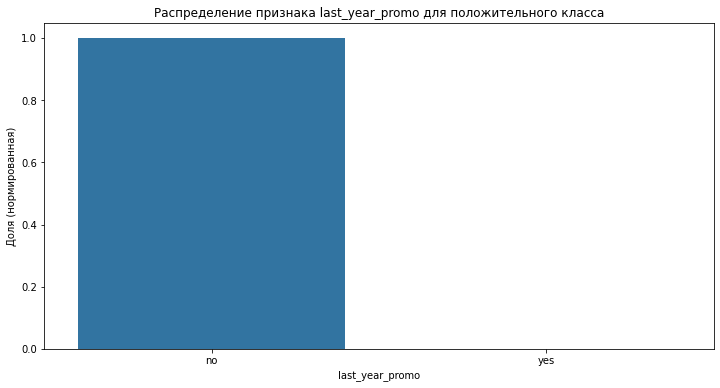

In [128]:
# Создаем DataFrame из Series для удобства построения
plot_data = last_year_promo_norm.reset_index()
plot_data.columns = ['last_year_promo', 'доля']

# Строим barplot
plt.figure(figsize=(12, 6))
sns.barplot(x='last_year_promo', y='доля', data=plot_data)
plt.ylabel('Доля (нормированная)')
plt.title('Распределение признака last_year_promo для положительного класса')
plt.show()

Видим, что за последний год уволившихся не повышали

In [129]:
last_year_violations_norm = positive_class_data['last_year_violations'].value_counts(normalize=True)

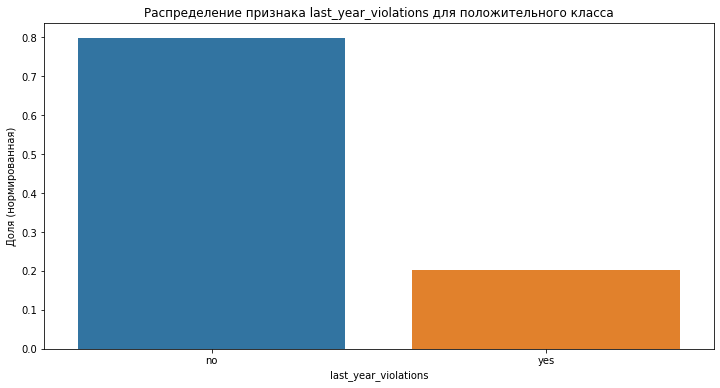

In [130]:
# Создаем DataFrame из Series для удобства построения
plot_data = last_year_violations_norm.reset_index()
plot_data.columns = ['last_year_violations', 'доля']

# Строим barplot
plt.figure(figsize=(12, 6))
sns.barplot(x='last_year_violations', y='доля', data=plot_data)
plt.ylabel('Доля (нормированная)')
plt.title('Распределение признака last_year_violations для положительного класса')
plt.show()

Видим, что большинство (около 80%) уволившихся нарушали трудовой договор за последний год

In [131]:
supervisor_evaluation_norm = positive_class_data['supervisor_evaluation'].value_counts(normalize=True)

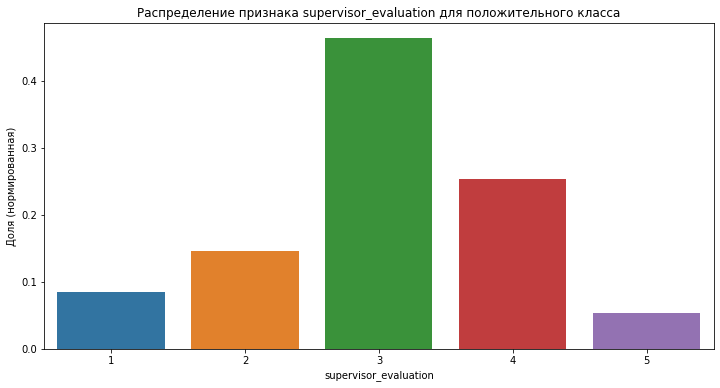

In [132]:
# Создаем DataFrame из Series для удобства построения
plot_data = supervisor_evaluation_norm.reset_index()
plot_data.columns = ['supervisor_evaluation', 'доля']

# Строим barplot
plt.figure(figsize=(12, 6))
sns.barplot(x='supervisor_evaluation', y='доля', data=plot_data)
plt.ylabel('Доля (нормированная)')
plt.title('Распределение признака supervisor_evaluation для положительного класса')
plt.show()

Видим, что в около половины уваолившихся наставник оценил на 3 балла.

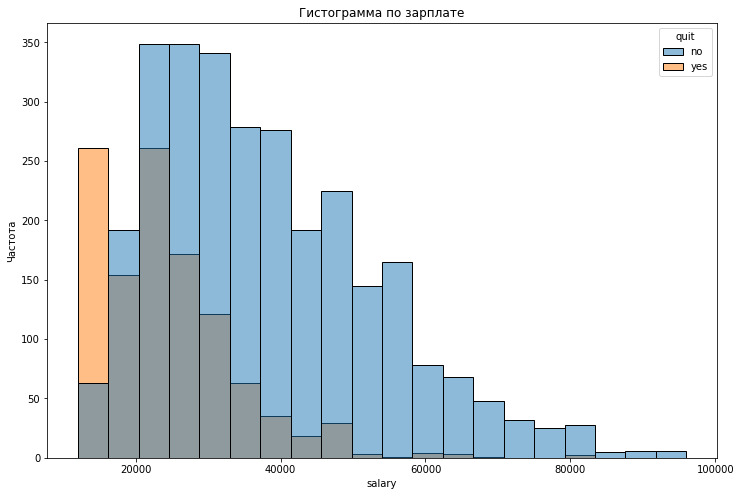

quit        salary       
                mean median
0   no  37702.228412  34800
1  yes  23885.106383  22800

In [133]:
fig, ax = plt.subplots(figsize=(12, 8))  # одна ось
sns.histplot(data=train_quit, x='salary', hue='quit', bins=20, ax=ax)
ax.set_title('Гистограмма по зарплате')
ax.set_ylabel('Частота')
plt.show()

train_quit.groupby('quit').agg({'salary': ['mean', 'median']}).reset_index()

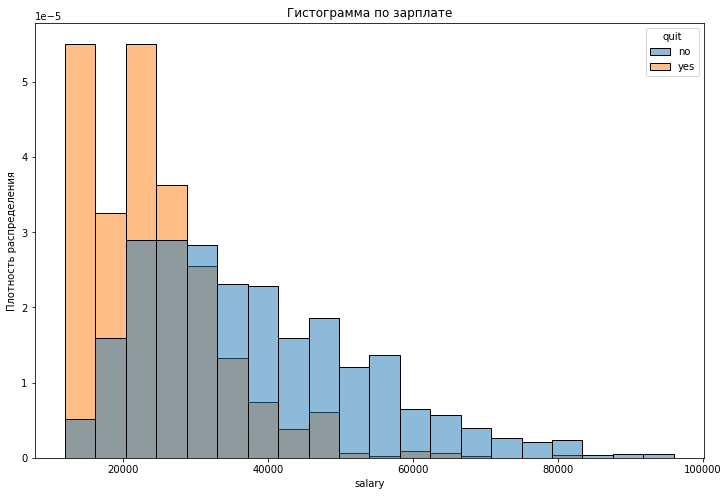

quit        salary       
                mean median
0   no  37702.228412  34800
1  yes  23885.106383  22800

In [134]:
fig, ax = plt.subplots(figsize=(12, 8))  # одна ось
sns.histplot(data=train_quit, x='salary', hue='quit', bins=20, ax=ax, stat='density', common_norm=False)


ax.set_title('Гистограмма по зарплате')
ax.set_ylabel('Плотность распределения')
plt.show()

train_quit.groupby('quit').agg({'salary': ['mean', 'median']}).reset_index()

Видим, что уволившиеся в среднем получали 23885, а оставшиеся в компании - 37702, медианные зарплаты по уволившимся - 22800, по отсвшимся - 34800

 ***Шаг 3.3 Исследование удовлетворенности в зависимости от факта ухода***

In [135]:
result = pd.merge(test_target_job_satisfaction_rate, test_target_quit, on='id', how='inner') 

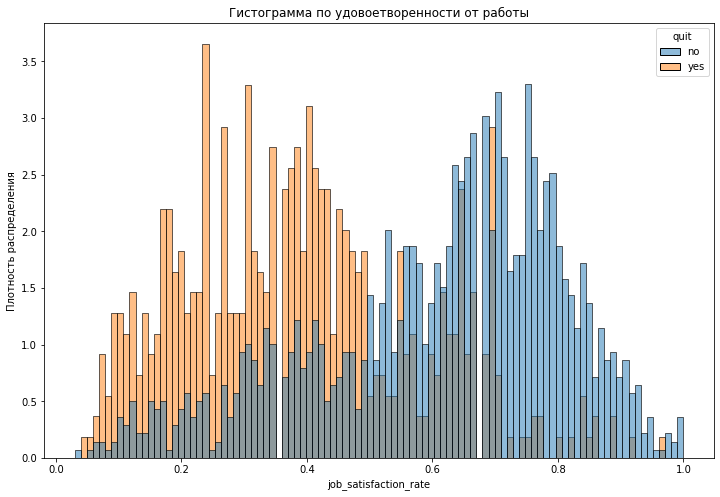

,quit,job_satisfaction_rate
0,no,0.66
1,yes,0.37


In [136]:
fig, ax = plt.subplots(figsize=(12, 8))  # одна ось
sns.histplot(data=result, x='job_satisfaction_rate', hue='quit', bins=100, ax=ax, stat='density', common_norm=False)


ax.set_title('Гистограмма по удовоетворенности от работы')
ax.set_ylabel('Плотность распределения')
plt.show()

result.groupby('quit').agg({'job_satisfaction_rate': 'median'}).reset_index()

Видим, что уволившиеся в среднем почти в два раза менее удовлетворены своей работой, чем оставшиеся в компании, при этом уровень их удовлетворенности составляет 0.37. В целом, мы видим, что распределение по уволившимся сотрудникам смещено влево относительно уровня удовлетворенности сотрудников, оставшихся в копани.

 ***Шаг 4 Добавление нового входного признака***

In [137]:
best_model = search_tree.best_estimator_
train_quit['job_satisfaction_rate'] = best_model.predict(train_quit)
train_quit

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
0,723290,sales,middle,high,2,no,no,4,54000,no,0.600000
1,814010,sales,junior,medium,2,no,no,4,27600,no,0.846364
2,155091,purchasing,middle,medium,5,no,no,1,37200,no,0.340000
3,257132,sales,junior,medium,2,no,yes,3,24000,yes,0.340000
4,910140,marketing,junior,medium,2,no,no,5,25200,no,0.690000
...,...,...,...,...,...,...,...,...,...,...,...
3995,588809,sales,junior,medium,4,no,no,3,26400,no,0.550000
3996,672059,sales,middle,high,9,no,no,4,52800,no,0.807500
3997,536432,purchasing,junior,low,2,no,yes,4,12000,yes,0.546667
3998,692133,purchasing,middle,medium,2,no,no,4,33600,no,0.553333


Проверим не появилась ли мультиколлинеарность после добавления нового признака

In [138]:
result_for_phik_train2 = train_quit.drop(columns=['id'])

In [139]:
phik_corr_train = phik_matrix(result_for_phik_train2, interval_cols=['salary', 'job_satisfaction_rate'])

In [140]:
result_for_phik_train2

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
0,sales,middle,high,2,no,no,4,54000,no,0.600000
1,sales,junior,medium,2,no,no,4,27600,no,0.846364
2,purchasing,middle,medium,5,no,no,1,37200,no,0.340000
3,sales,junior,medium,2,no,yes,3,24000,yes,0.340000
4,marketing,junior,medium,2,no,no,5,25200,no,0.690000
...,...,...,...,...,...,...,...,...,...,...
3995,sales,junior,medium,4,no,no,3,26400,no,0.550000
3996,sales,middle,high,9,no,no,4,52800,no,0.807500
3997,purchasing,junior,low,2,no,yes,4,12000,yes,0.546667
3998,purchasing,middle,medium,2,no,no,4,33600,no,0.553333


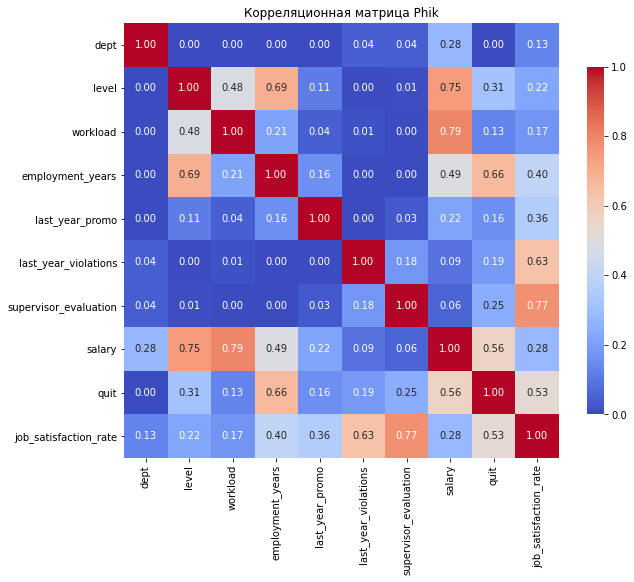

In [141]:
plt.figure(figsize=(10, 8))  
sns.heatmap(phik_corr_train, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title('Корреляционная матрица Phik')
plt.show()


Мультиколлинеарность после добавелния нового признака отсутствует

Теперь добавим новый признак также в тестовую выборку

In [142]:
test_merged_2 = test_target_quit.merge(test_features_2, how='right', on='id')

In [143]:
test_merged_2.drop('id', axis=1, inplace=True)

In [144]:
test_merged_2['job_satisfaction_rate'] = best_model.predict(test_merged_2)

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:188: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [145]:
phik_corr_test_2 = phik_matrix(test_merged_2, interval_cols=['salary', 'job_satisfaction_rate'])

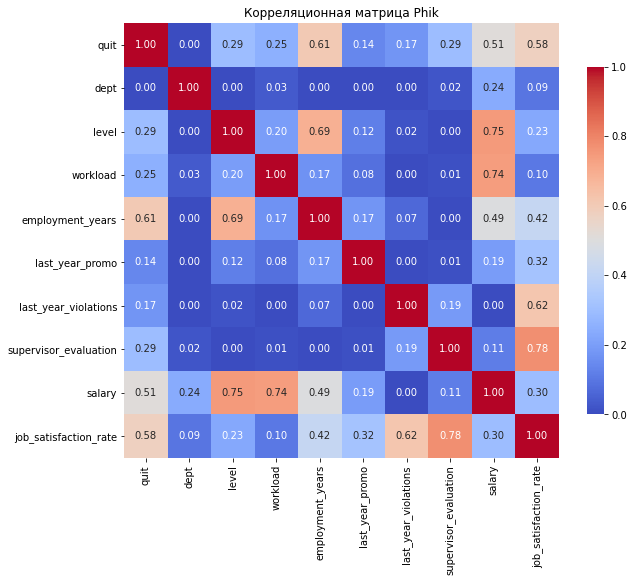

In [146]:
plt.figure(figsize=(10, 8))
sns.heatmap(phik_corr_test_2, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title('Корреляционная матрица Phik')
plt.show()

Видим, что как в тренировочных , так и в тестовых мультиколлинеарность отсутствует. Более того, мультиколлинеарность, оторая была первоначально в тестовом наботе с добавлением нового ушла (хотя свзя все же высокая)

 ***Шаг 5 Подготовка данных***

In [158]:
RANDOM_STATE = 42
TEST_SIZE = 0.25


X_train = train_quit.drop(['quit', 'id'], axis=1)
y_train = train_quit['quit']


test_merged_2['job_satisfaction_rate'] = best_model.predict(test_merged_2)

test_target_quit = test_merged_2['quit']
X_test= test_merged_2.drop('quit', axis=1)
y_test = test_target_quit

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:188: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [159]:
# создаём списки с названиями признаков
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']
ord_columns = ['level', 'workload']
num_columns = ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']

In [160]:
# создаём пайплайн для подготовки признаков с помощью OHE из списка ohe_columns
ohe_pipe = Pipeline(
    [('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False))]
    )

# создаём пайплайн для подготовки признаков с помощью ORD из списка ord_columns
ord_pipe = Pipeline(
    [('ord',  OrdinalEncoder(
            categories= [
                ['junior', 'middle', 'sinior', np.nan],
                ['medium', 'high', 'low'],
            ], 
            handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [161]:
param_grid = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 5),
        'models__max_features': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    
    # словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]   
    },

    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]  
    },
]

In [162]:
# На обучающей выборке (только один раз)
label_enc = LabelEncoder()
y_train = label_enc.fit_transform(y_train)  # Обучаем энкодер на тренировочных метках

# На тестовой выборке
y_test_encoded = label_enc.transform(y_test)

In [163]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
randomized_search.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели на валидационной выборке:', randomized_search.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                                                  Pipeline(steps=[('ord',
                                                                   OrdinalEncoder(categories=[['junior',
                                                     

In [164]:
# проверка работы модели на тестовой выборке
# расчет прогноза на тестовых данных
y_test_pred = randomized_search.predict_proba(X_test)[:, 1]
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test_encoded, y_test_pred)}')

Метрика ROC-AUC на тестовой выборке: 0.9175167674193485


/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:188: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [165]:
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train)

# Предсказания для вероятностей
dummy_probs = dummy_clf.predict_proba(test_merged_2.drop('quit', axis=1, inplace=False))[:, 1]

print(f"Метрика ROC-AUC на тестовой выборке: {roc_auc_score(test_merged_2['quit'], dummy_probs):.2f}%")

Метрика ROC-AUC на тестовой выборке: 0.50%


***Вывод: лучший результат показала модель LogisticRegression с параметрами C=4, penalty='l1', solver='liblinear'***

# Общий вывод по проекту:

Проведенная работа состояла из двух частей.
Первая часть состояла в построении модели предсказания уровня удовлетворённости сотрудника на основе данных заказчика.

- На первом этапе мы познакомились с представленными заказчиком данными, данные соответствовали описанию.
- На этапе предобработки данных увидели отдельные пропуски в датасетах, однако оставили их обработку до этапа построения пайплайна, полные дубликаты отсутствовали, типы данных соответствовали содержанию столбцов.
- На этапе исследовательского анализа данных мы рассмотрели характер распределений признаков и таргета, нормально распределенные признаки отсутствовали. Были категориальные номинальные и порядковые признаки, дискретные и непрервные, поэтому в дальнейшем приняты было построить матрицу корреляций Phik. В целом, признаки в тренировочном и тестовом датасетах были распределены похожим образом.
- На этапе корреляционного анализа данных мы увидели,  что сильнее всего целевой признак (Job_satisfaction_rate) связан  с supervisor_evaluation. Также  значимая связь имеется с last_year_violations. С employment_years связь умеренная. Мультиколлинеарности не было. Увидели,  что существенных различий в связи таргета и входящих признаков в тестовой выборке по сравнению с тренировочной нет, оценка модели, которую получим на тестовой выборке, будет корректной.
- Далее мы построили пайплайн, который использовал две модели: DecisionTreeRegressor и LinearREgression, так как нам необходимо было предсказать непрерывный целевой признак. В  качестве метрики использовалась SMAPE («симметричное среднее абсолютное процентное отклонение»). Лучше всего себя показал DecisionTreeRegressor с параметрами: max_depth=96, max_features=24, min_samples_split=5, на тестовой выборке получили значение 13.93%, на валидационной - 15.24%. При этом наша модель прошла проверку сравнением с DummyRegressor.

Рекомендации по первой части: чтобы увеличивать уровень удовлетворенности необходимо с аккуратностью ставить низкие оценки сотрудникам - от этого сильнее всего зависела удовлетворенность работой сотрудников. Также стоит удерживать сотрудников в компании дольше - это тоже сказывается прямым образом на их удовлетворенности работой. Кроме того, пытаться как-то предупредить нарушения трудового договора сотрудником.

Во второй части надлежало предсказать увольнение сотрудника из компании.

- На первом этапе мы познакомились с представленными заказчиком данными, данные соответствовали описанию.
-  На этапе предобработки данных увидели отдельные пропуски в датасетах, однако оставили их обработку до этапа построения пайплайна, полные дубликаты отсутствовали, типы данных соответствовали содержанию столбцов.
- На этапе исследовательского анализа мы рассмотрели распределения входящих признаков и таргета. Данные в тестовой и тренировочной выборках были распределены схожим образом. На этапе корреляционного анализа увидели, сильней всего целевой признак был связан с 'employment_years' и 'salary'. В целом,  связи целевой переменной и входных признаков в тренировочной и тестовых выборках похожи.
- Портрет уволившегося сотрудника: работает около года, из отдела продаж, занимает джуниор-позицию, имел на работе либо низкую, либо среднюю загруженность, за последний год его не повышали, нарушал трудовой договор за последний год, наставник оценивал его на три балл. зарплата около 22800
- уволившиеся в среднем почти в два раза менее удовлетворены своей работой, чем оставшиеся в компании, при этом уровень их удовлетворенности составляет 0.37.
- Далее мы добавили новый входной признак на основе работы первой модели, а именно - job_satisfaction_rate, который был значимо связан с таргетом.
- При построении пайплайна использовались три модели - DecisionTreeClassifier, KNeighborsClassifier, LogisticRegression. Лучший результат (метрика ROC-AUC на тестовой выборке: 0.92) показала LogisticRegression с параметрами C=4, penalty='l1', solver='liblinear'.

Рекомендации по второй части: как можно скорее начинать повышать нагрузку на работника, при этом повышая ему зарплату и переводя с джуниорских позиций, следить за уровнем его удовлетворенности от работы.